In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.anova import AnovaRM
from matplotlib.lines import Line2D
from scipy.stats import t as tdist
from statsmodels.formula.api import glm
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.multitest import multipletests
import seaborn as sns

In [2]:
input_path = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe_obj_fovfiltered.csv"
df = pd.read_csv(input_path)

print("Loaded dataframe shape:", df.shape)
print("Columns preview:")
print(df.columns.tolist()[:30])

C:\Users\Marcel\AppData\Local\Temp\ipykernel_11812\2063978927.py:2: DtypeWarning: Columns (67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


Loaded dataframe shape: (3270015, 69)
Columns preview:
['index', 'SubjectID', 'Session', 'SessionSubsection', 'timeStampDataPointEnd', 'combinedGazeValidityBitmask', 'eyePositionCombinedWorld.x', 'eyePositionCombinedWorld.y', 'eyePositionCombinedWorld.z', 'eyeDirectionCombinedWorld.x', 'eyeDirectionCombinedWorld.y', 'eyeDirectionCombinedWorld.z', 'eyeDirectionCombinedLocal.x', 'eyeDirectionCombinedLocal.y', 'eyeDirectionCombinedLocal.z', 'playerBodyPosition.x', 'playerBodyPosition.y', 'playerBodyPosition.z', 'hitColliderType', 'hitPointOnObject_x', 'hitPointOnObject_y', 'hitPointOnObject_z', 'Eucledian_distance', 'Face_Hits', 'Time_Shift', ' eyePositionCombinedWorld.x', 'combined_vel', 'thresh', 'isFix', 'corrected_vel']


In [3]:
# =====================================================================
# Building the context dataframe
# =====================================================================

SUBJ  = "SubjectID"
SESS  = "Session"
TIME  = "total_time"
EVENT = "events"                  #  1 onset, -1 end; 2 fixation start, -2 fixation end
LEN   = "length"                  #  seconds on saccade ONSET row
NAME  = "names"
CATM  = "ObjectCategoryMerged"
VAL   = "combinedGazeValidityBitmask"
LONG  = "long_events"
RESID = "ResidualClassAmpDur"     # -1 faster/shorter, 0 middle, +1 slower/longer
BIN   = "AmpBin"                  # numeric int bins (1..NUM_BINS)
AMP   = "saccade_amplitude_deg"
DIST  = "avg_dist"
HEADV = "head_velocity_magnitude_deg_per_s"
MODE  = "saccade_mode"            # 1 = Short, 2 = Long
PVEL  = "saccade_peak_velocity_deg_per_s"
EXCL  = "exclude_object"
RET   = "retinal_image_area_deg2"

PRE_WIN_S  = 0.200
POST_WIN_S = 0.200

# ----------------- index helpers -----------------
def _prev_index(idxs, i):
    if len(idxs) == 0:
        return None
    pos = np.searchsorted(idxs, i, side="left") - 1
    return int(idxs[pos]) if pos >= 0 else None

def _next_index(idxs, i):
    if len(idxs) == 0:
        return None
    pos = np.searchsorted(idxs, i, side="right")
    return int(idxs[pos]) if pos < len(idxs) else None

def find_immediate_prev_fixation(evB, okB, start_idx):
    """
    Find the immediate previous fixation (start+end) before start_idx.
    Returns (i_fxS, i_fxE) or (None, None).
    Requires BOTH start and end rows to be valid (okB == True).
    Does NOT skip over invalid fixations.
    """
    n = len(evB)

    # find nearest fixation start going backwards
    i_fxS = None
    for j in range(start_idx - 1, -1, -1):
        if evB[j] == 2.0:     # fixation start
            i_fxS = j
            break
        if evB[j] == 1.0:     # hit another saccade onset first → give up
            break

    if i_fxS is None or not okB[i_fxS]:
        return None, None

    # find corresponding fixation end going forwards
    i_fxE = None
    for j in range(i_fxS + 1, n):
        if evB[j] == -2.0:    # fixation end
            i_fxE = j
            break
        if evB[j] in (2.0, 1.0):  # malformed sequence
            break

    if i_fxE is None or not okB[i_fxE]:
        return None, None

    return i_fxS, i_fxE

def find_immediate_next_fixation(evB, okB, start_idx):
    """
    Find the immediate next fixation (start+end) after start_idx.
    Returns (i_fxS, i_fxE) or (None, None).
    Requires BOTH start and end rows to be valid.
    Does NOT skip over invalid fixations.
    """
    n = len(evB)

    # nearest fixation start going forward
    i_fxS = None
    for j in range(start_idx + 1, n):
        if evB[j] == 2.0:
            i_fxS = j
            break
        if evB[j] == 1.0:     # hit another saccade before any fixation
            break

    if i_fxS is None or not okB[i_fxS]:
        return None, None

    i_fxE = None
    for j in range(i_fxS + 1, n):
        if evB[j] == -2.0:
            i_fxE = j
            break
        if evB[j] in (2.0, 1.0):
            break

    if i_fxE is None or not okB[i_fxE]:
        return None, None

    return i_fxS, i_fxE

def find_immediate_prev_saccade(evB, okB, start_idx):
    """
    Immediate previous saccade onset before start_idx.
    Returns index or None. Requires onset to be valid.
    We do NOT stop at fixations – we want the nearest onset in time.
    """
    for j in range(start_idx - 1, -1, -1):
        if evB[j] == 1.0:
            return j if okB[j] else None
    return None

def find_immediate_next_saccade(evB, okB, start_idx):
    """
    Immediate next saccade onset after start_idx.
    Returns index or None. Requires onset to be valid.
    We do NOT stop at fixations – we want the nearest onset in time.
    """
    n = len(evB)
    for j in range(start_idx + 1, n):
        if evB[j] == 1.0:
            return j if okB[j] else None
    return None

# ----------------- validity for timeline rows -----------------
val_arr  = df[VAL].to_numpy()
long_arr = df[LONG].to_numpy()

ok = (val_arr == 3) & (~np.isnan(long_arr))

# Keep core arrays for speed (assumes df is sorted by Subject/Session/time)
t        = df[TIME].to_numpy()
ev       = df[EVENT].to_numpy()
durS     = df[LEN].to_numpy()                # seconds
nm       = df[NAME].to_numpy(object) if NAME in df.columns else np.array([np.nan] * len(df), dtype=object)
catM     = df[CATM].to_numpy(object) if CATM in df.columns else np.array([np.nan] * len(df), dtype=object)
binv     = df[BIN].to_numpy()                # numeric bins or NaN
resC     = df[RESID].to_numpy()              # -1/0/+1 or NaN
sid      = df[SUBJ].to_numpy()
ses      = df[SESS].to_numpy()
amp      = df[AMP].to_numpy()
dist     = df[DIST].to_numpy()
head     = df[HEADV].to_numpy()
mode_arr = df[MODE].to_numpy() if MODE in df.columns else np.full(len(df), np.nan)
pvel     = df[PVEL].to_numpy() if PVEL in df.columns else np.full(len(df), np.nan)
excl     = df[EXCL].to_numpy()
ret      = df[RET].to_numpy() if RET in df.columns else np.full(len(df), np.nan)

# ----------------- build per-saccade context rows -----------------
rows = []

# novelty trackers per subject-session
last_seen_end_time = {}   # (sid,sess) -> dict[name] = last fixation end time
seen_names = {}           # (sid,sess) -> set of names seen so far (for prev_novel)

for (sid_i, ses_i), idxs in df.groupby([SUBJ, SESS], sort=False).indices.items():
    a = np.array(sorted(idxs))  # indices for this block

    # local views
    tB, evB, durB, nmB, catMB, okB, binB, resB, ampB, distB, headB, modeB, pvelB, exclB, retB = (
        t[a],
        ev[a],
        durS[a],
        nm[a],
        catM[a],
        ok[a],
        binv[a],
        resC[a],
        amp[a],
        dist[a],
        head[a],
        mode_arr[a],
        pvel[a],
        excl[a],
        ret[a],
    )

    last_t = last_seen_end_time.setdefault((sid_i, ses_i), {})
    seen   = seen_names.setdefault((sid_i, ses_i), set())

    idx_on  = np.flatnonzero((evB ==  1.0) & okB)  # valid saccade onsets in this block
    idx_end = np.flatnonzero(evB == -1.0)
    idx_fxS = np.flatnonzero((evB ==  2.0) & okB)
    idx_fxE = np.flatnonzero(evB == -2.0)

    for loc_on in idx_on:
        # ----- Short / Long label from saccade_mode -----
        m = modeB[loc_on]
        if not np.isfinite(m):
            # no mode label -> skip this saccade for context
            continue
        m_int = int(m)
        if m_int == 1:
            sacc_mode_lbl = "Short"
        elif m_int == 2:
            sacc_mode_lbl = "Long"
        else:
            # unknown code – skip
            continue

        # ----- Residual label (keep all classes, including middle) -----
        rc = resB[loc_on]
        if np.isfinite(rc):
            rc_int = int(rc)
            if rc_int == -1:
                residual = "Faster"
            elif rc_int == 0:
                residual = "Middle"
            elif rc_int == 1:
                residual = "Slower"
            else:
                residual = np.nan
        else:
            residual = np.nan

        # ----- amplitude bin label (may be NaN if not in s) -----
        abin = binB[loc_on]
        amp_bin = int(abin) if np.isfinite(abin) else np.nan

        # ----- CURRENT saccade properties -----
        curr_sacc_amp_deg = float(ampB[loc_on]) if np.isfinite(ampB[loc_on]) else np.nan
        curr_sacc_peak_vel = float(pvelB[loc_on]) if np.isfinite(pvelB[loc_on]) else np.nan

        sacc_t_start = tB[loc_on]
        curr_len_s   = float(durB[loc_on]) if np.isfinite(durB[loc_on]) else np.nan

        # one-row vs two-row saccade, i_end as before
        i_nextrow    = loc_on + 1 if (loc_on + 1) < len(a) else None
        use_one_row  = (i_nextrow is not None and evB[i_nextrow] == 2.0)
        if use_one_row:
            i_end = loc_on
        else:
            i_end = _next_index(idx_end, loc_on)

        t_end = sacc_t_start + (curr_len_s if np.isfinite(curr_len_s) else 0.0)
        if use_one_row:
            sacc_t_end = np.nan
        else:
            sacc_t_end = tB[i_end] if i_end is not None and 0 <= i_end < len(tB) else np.nan

        # ---------- STRICT previous fixation ----------
        prev_catM = np.nan
        prev_name = np.nan
        prev_fix_ms = np.nan
        prev_dist = np.nan
        prev_is_novel = np.nan
        prev_retinal_area = np.nan

        i_fxS_prev, i_fxE_prev = find_immediate_prev_fixation(evB, okB, loc_on)
        if i_fxS_prev is not None and i_fxE_prev is not None:
            prev_catM = catMB[i_fxS_prev]
            prev_name = nmB[i_fxS_prev]
            prev_fix_ms = float((tB[i_fxE_prev] - tB[i_fxS_prev]) * 1000.0)
            prev_dist = float(distB[i_fxS_prev]) if np.isfinite(distB[i_fxS_prev]) else np.nan

            if np.isfinite(exclB[i_fxS_prev]) and exclB[i_fxS_prev] != 1:
                prev_retinal_area = float(retB[i_fxS_prev]) if np.isfinite(retB[i_fxS_prev]) else np.nan

            nm_prev = nmB[i_fxS_prev]
            if isinstance(nm_prev, str):
                prev_is_novel = float(nm_prev not in seen)
                seen.add(nm_prev)

        # ---------- STRICT next fixation ----------
        next_catM = np.nan
        next_name = np.nan
        next_dist = np.nan
        post_fix_ms = np.nan
        next_is_novel = np.nan
        is_face_target = np.nan
        is_landmark_target = np.nan
        next_retinal_area = np.nan

        start_for_next_fix = i_end if i_end is not None else loc_on
        i_fxS_next, i_fxE_next = find_immediate_next_fixation(evB, okB, start_for_next_fix)
        if i_fxS_next is not None and i_fxE_next is not None:
            next_catM = catMB[i_fxS_next]
            next_name = nmB[i_fxS_next]
            next_dist = float(distB[i_fxS_next]) if np.isfinite(distB[i_fxS_next]) else np.nan
            post_fix_ms = float((tB[i_fxE_next] - tB[i_fxS_next]) * 1000.0)

            if np.isfinite(exclB[i_fxS_next]) and exclB[i_fxS_next] != 1:
                next_retinal_area = float(retB[i_fxS_next]) if np.isfinite(retB[i_fxS_next]) else np.nan

            if isinstance(next_catM, str):
                is_face_target     = float(next_catM == "Face")
                is_landmark_target = float(next_catM == "Landmark")

            if isinstance(next_name, str):
                last_time = last_t.get(next_name, None)
                next_is_novel = float(last_time is None)
                last_t[next_name] = tB[i_fxE_next]

        # ---------- flags that depend on BOTH fixations ----------
        within_object = np.nan
        category_switch = np.nan

        if isinstance(prev_name, str) and isinstance(next_name, str):
            within_object = float(prev_name == next_name)

        if isinstance(prev_catM, str) and isinstance(next_catM, str):
            category_switch = float(prev_catM != next_catM)

        # ---------- STRICT previous saccade ----------
        prev_sacc_amp_deg = np.nan
        prev_sacc_dur_ms  = np.nan

        i_prev_on_raw = find_immediate_prev_saccade(evB, okB, loc_on)
        if i_prev_on_raw is not None:
            if np.isfinite(ampB[i_prev_on_raw]):
                prev_sacc_amp_deg = float(ampB[i_prev_on_raw])
            if np.isfinite(durB[i_prev_on_raw]):
                prev_sacc_dur_ms  = float(durB[i_prev_on_raw] * 1000.0)

        # ---------- STRICT next saccade ----------
        next_sacc_amp_deg = np.nan
        next_sacc_dur_ms  = np.nan

        start_for_next_sacc = i_end if i_end is not None else loc_on
        i_next_on_raw = find_immediate_next_saccade(evB, okB, start_for_next_sacc)
        if i_next_on_raw is not None:
            if np.isfinite(ampB[i_next_on_raw]):
                next_sacc_amp_deg = float(ampB[i_next_on_raw])
            if np.isfinite(durB[i_next_on_raw]):
                next_sacc_dur_ms  = float(durB[i_next_on_raw] * 1000.0)

        # ---------- head-movement context ----------
        pre_mask  = (tB >= (sacc_t_start - PRE_WIN_S)) & (tB < sacc_t_start)
        post_mask = (tB >= t_end) & (tB < (t_end + POST_WIN_S))

        head_pre_vals  = headB[pre_mask] if np.any(pre_mask) else np.array([])
        head_post_vals = headB[post_mask] if np.any(post_mask) else np.array([])

        if head_pre_vals.size and np.isfinite(head_pre_vals).any():
            head_pre = float(np.nanmean(head_pre_vals))
        else:
            head_pre = np.nan

        if head_post_vals.size and np.isfinite(head_post_vals).any():
            head_post = float(np.nanmean(head_post_vals))
        else:
            head_post = np.nan

        # ---------- append row ----------
        rows.append({
            "SubjectID": sid_i,
            "Session": ses_i,
            "AmpBin": amp_bin,
            "Residual": residual,
            "Saccade_Mode": sacc_mode_lbl,
            "sacc_len_s": curr_len_s,
            "sacc_t_start": sacc_t_start,
            "sacc_t_end": sacc_t_end,
            "sacc_amp_deg": curr_sacc_amp_deg,
            "sacc_peak_vel_deg_s": curr_sacc_peak_vel,

            "prev_name": prev_name,
            "next_name": next_name,
            "prev_catM": prev_catM,
            "next_catM": next_catM,

            "within_object": within_object,
            "category_switch": category_switch,
            "next_is_novel": float(next_is_novel) if np.isfinite(next_is_novel) else np.nan,
            "prev_is_novel": float(prev_is_novel) if np.isfinite(prev_is_novel) else np.nan,

            "prev_fix_ms": prev_fix_ms,
            "prev_sacc_amp_deg": prev_sacc_amp_deg,
            "prev_sacc_dur_ms": prev_sacc_dur_ms,
            "post_fix_ms": post_fix_ms,
            "next_sacc_amp_deg": next_sacc_amp_deg,
            "next_sacc_dur_ms": next_sacc_dur_ms,

            "is_face_target": is_face_target,
            "is_landmark_target": is_landmark_target,

            "prev_dist": prev_dist,
            "next_dist": next_dist,

            "prev_retinal_image_area_deg2": prev_retinal_area,
            "next_retinal_image_area_deg2": next_retinal_area,

            "head_pre": head_pre,
            "head_post": head_post,
        })

ctx_all = pd.DataFrame.from_records(rows)
print("Context extraction finished. Shape:", ctx_all.shape)

Context extraction finished. Shape: (142767, 32)


Previous retinal image area:
count    78667.000000
mean       794.962905
std       1358.445304
min          0.022159
25%         47.582649
50%        208.483607
75%        864.870725
max       9524.830282
Name: prev_retinal_image_area_deg2, dtype: float64

Next retinal image area:
count    79955.000000
mean       798.104507
std       1360.724111
min          0.022159
25%         48.040846
50%        210.866072
75%        871.196181
max       9524.830282
Name: next_retinal_image_area_deg2, dtype: float64


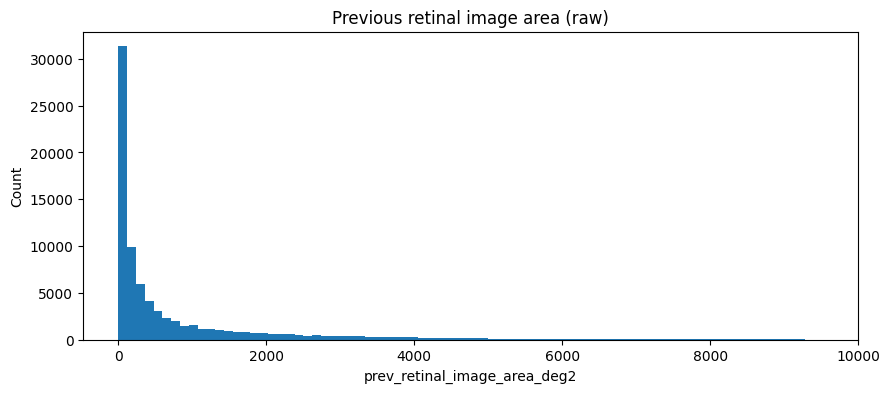

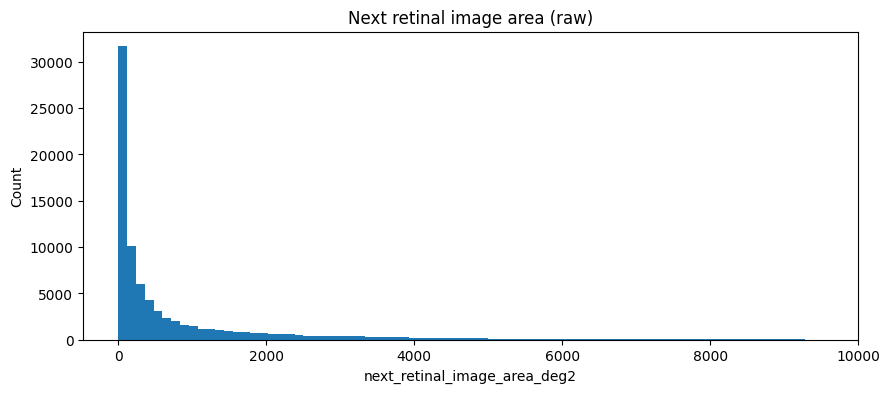

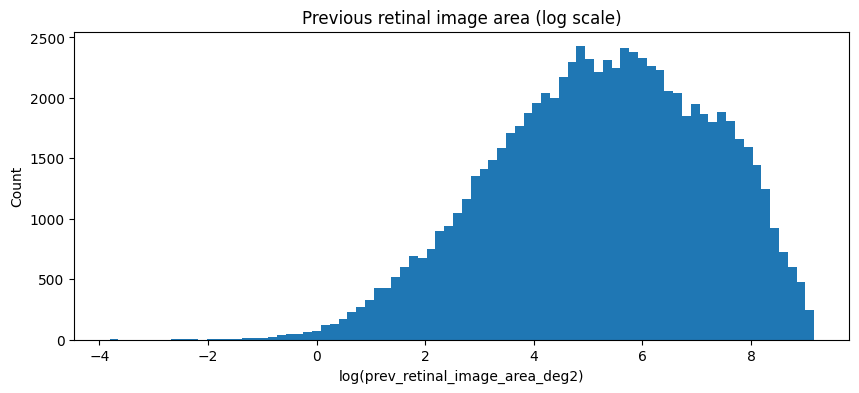

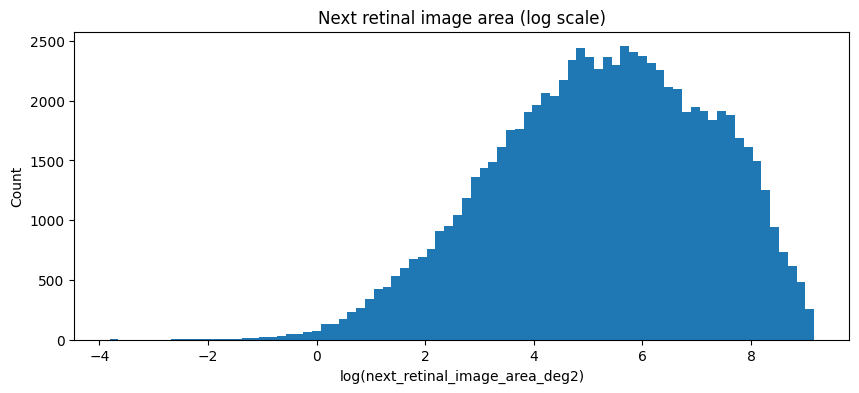

In [4]:
prev_col = "prev_retinal_image_area_deg2"
next_col = "next_retinal_image_area_deg2"

# Make sure numeric
ctx_all[prev_col] = pd.to_numeric(ctx_all[prev_col], errors="coerce")
ctx_all[next_col] = pd.to_numeric(ctx_all[next_col], errors="coerce")

prev_vals = ctx_all[prev_col].dropna()
next_vals = ctx_all[next_col].dropna()

prev_pos = prev_vals[prev_vals > 0]
next_pos = next_vals[next_vals > 0]

print("Previous retinal image area:")
print(prev_vals.describe())
print("\nNext retinal image area:")
print(next_vals.describe())

# -----------------------------
# Raw distributions
# -----------------------------
plt.figure(figsize=(10, 4))
plt.hist(prev_vals, bins=80)
plt.title("Previous retinal image area (raw)")
plt.xlabel("prev_retinal_image_area_deg2")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(next_vals, bins=80)
plt.title("Next retinal image area (raw)")
plt.xlabel("next_retinal_image_area_deg2")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Log-transformed distributions
# -----------------------------
plt.figure(figsize=(10, 4))
plt.hist(np.log(prev_pos), bins=80)
plt.title("Previous retinal image area (log scale)")
plt.xlabel("log(prev_retinal_image_area_deg2)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(np.log(next_pos), bins=80)
plt.title("Next retinal image area (log scale)")
plt.xlabel("log(next_retinal_image_area_deg2)")
plt.ylabel("Count")
plt.show()

In [5]:
# ---------------------------------------------------------------------
# Attach entry_nr and street_id_within_participant to saccades in ctx_all
# and compute times relative to turn onset.
# ---------------------------------------------------------------------

ENTRY  = "entry_nr"
STREET = "street_id_within_participant"

# Initialise new columns in ctx_all
ctx_all[ENTRY]                = np.nan
ctx_all[STREET]               = np.nan
ctx_all["t_start_since_turn"] = np.nan
ctx_all["t_end_since_turn"]   = np.nan

# Loop per subject
for sid_i, df_sub in df.groupby(SUBJ, sort=False):

    mask_sacc = (ctx_all["SubjectID"] == sid_i)
    sacc_sub  = ctx_all.loc[mask_sacc]

    # Saccade start / end
    s_start = sacc_sub["sacc_t_start"].to_numpy()
    s_end   = sacc_sub["sacc_t_end"].to_numpy()

    # Effective end = true end OR start + duration
    s_len = sacc_sub["sacc_len_s"].to_numpy()
    s_end_effective = np.where(np.isfinite(s_end), s_end, s_start + s_len)

    # Turn onset rows
    turn_rows = df_sub.loc[df_sub[ENTRY].notna(), [TIME, ENTRY, STREET]]

    # For each turn, apply classification for saccades in [t0, t0+10]
    for _, turn in turn_rows.iterrows():
        t0 = float(turn[TIME])
        t1 = t0 + 10.0

        in_window = (
            (s_start >= t0) &
            np.isfinite(s_end_effective) &
            (s_end_effective <= t1)
        )

        idx_to_update = sacc_sub.index[in_window]

        # Assign identifiers
        ctx_all.loc[idx_to_update, ENTRY]  = turn[ENTRY]
        ctx_all.loc[idx_to_update, STREET] = turn[STREET]

        # Relative times
        ctx_all.loc[idx_to_update, "t_start_since_turn"] = s_start[in_window] - t0
        ctx_all.loc[idx_to_update, "t_end_since_turn"]   = s_end_effective[in_window] - t0

print("Annotated ctx_all with entry_nr, street_id_within_participant, and relative timing.")

print(ctx_all.head(10).to_string(index=False))


Annotated ctx_all with entry_nr, street_id_within_participant, and relative timing.
 SubjectID  Session  AmpBin Residual Saccade_Mode  sacc_len_s  sacc_t_start  sacc_t_end  sacc_amp_deg  sacc_peak_vel_deg_s        prev_name       next_name  prev_catM  next_catM  within_object  category_switch  next_is_novel  prev_is_novel  prev_fix_ms  prev_sacc_amp_deg  prev_sacc_dur_ms  post_fix_ms  next_sacc_amp_deg  next_sacc_dur_ms  is_face_target  is_landmark_target  prev_dist  next_dist  prev_retinal_image_area_deg2  next_retinal_image_area_deg2   head_pre  head_post  entry_nr  street_id_within_participant  t_start_since_turn  t_end_since_turn
      1031        1    11.0   Faster        Short    0.011408      0.029264         NaN      3.182122           149.197797   pavement_O.002  pavement_O.002 Background Background            1.0              0.0            1.0            1.0     9.424210                NaN               NaN    21.327019           1.481300         61.008215             0.0   

In [6]:
# Two subsets:
ctx_shortlong    = ctx_all[ctx_all["Saccade_Mode"].isin(["Short", "Long"])].copy()
ctx_fasterslower = ctx_all[ctx_all["Residual"].isin(["Faster", "Slower"])].copy()
ctx_entries      = ctx_all[ctx_all["entry_nr"].notna()].copy()

print("Short/Long subset:", ctx_shortlong.shape)
print("Faster/Slower subset:", ctx_fasterslower.shape)
print("Entries subset:", ctx_entries.shape)


# Save the context dataframes
out_shortlong    = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_shortlong.csv"
out_fasterslower = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_fasterslower.csv"
out_entries      = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_entries.csv"
out_all = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_allsaccades.csv"

ctx_shortlong.to_csv(out_shortlong, index=False)
ctx_fasterslower.to_csv(out_fasterslower, index=False)
ctx_entries.to_csv(out_entries, index = False)
ctx_all.to_csv(out_all, index = False)

Short/Long subset: (142767, 36)
Faster/Slower subset: (72626, 36)
Entries subset: (15942, 36)


In [3]:
import pandas as pd
import numpy as np

# ===================== Parameters =====================
CSV = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe_obj_fovfiltered.csv"
OUT_CSV = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_fixations.csv"
PRE_WINDOW_S = 0.100  # 100 ms

# ===================== Column names =====================
SUBJ   = "SubjectID"
SESS   = "Session"
EVENT  = "events"                              # 2 = fixation start, -2 = fixation end
VALID  = "combinedGazeValidityBitmask"
LONG   = "long_events"
TIME   = "total_time"                          # seconds, monotonically increasing within session
LEN    = "length"
NAME   = "names"
CAT    = "categorical_names"
CATM   = "ObjectCategoryMerged"
AVG_D  = "avg_dist"
HEADV  = "head_velocity_magnitude_deg_per_s"
EYEV   = "angular_gaze_velocity_smoothed"
EYEVU  = "angular_gaze_velocity_smoothed_unclipped"
RET    = "retinal_image_area_deg2"
SACCPV = "saccade_peak_velocity_deg_per_s"

# ===================== Load and coerce =====================
df = pd.read_csv(CSV)

# Coerce numeric columns that we will use for filtering/averaging
for c in [EVENT, VALID, LONG, TIME, LEN, AVG_D, HEADV, EYEV, EYEVU, RET, SACCPV]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Coerce identifiers as strings
df[SUBJ] = df[SUBJ].astype(str)
df[SESS] = df[SESS].astype(str)

# Sort to guarantee temporal order inside each session
df = df.sort_values([SUBJ, SESS, TIME], kind="mergesort").reset_index(drop=True)

# ===================== Valid fixation rows =====================
# Criteria: events == 2 AND combinedGazeValidityBitmask != 0 AND long_events not NaN
fix_mask = (df[EVENT] == 2) & df[VALID].notna() & (df[VALID] != 0) & df[LONG].notna()

# Keep only truly valid fixations (and TIME not NaN)
fix_mask &= df[TIME].notna()

# ===================== Helper: mean head velocity in prior window =====================
def mean_head_vel_prior(group_df: pd.DataFrame, t_fix: float, window_s: float) -> float:
    """
    Compute the arithmetic mean of HEADV over [t_fix - window_s, t_fix),
    using all rows in the same (SubjectID, Session) group.
    Ignores NaNs in HEADV. Returns np.nan if no samples in the window.
    """
    a = group_df[TIME].to_numpy()
    m = (a >= (t_fix - window_s)) & (a < t_fix)
    if not np.any(m):
        return float("nan")
    vals = group_df.loc[m, HEADV].to_numpy(dtype=float)
    if vals.size == 0:
        return float("nan")
    return float(np.nanmean(vals))

# ===================== Helper: mean eye velocity (smoothed) in prior window =====================
def mean_eye_vel_prior(group_df: pd.DataFrame, t_fix: float, window_s: float) -> float:
    """
    Compute the arithmetic mean of EYEV over [t_fix - window_s, t_fix),
    using all rows in the same (SubjectID, Session) group.
    Ignores NaNs in EYEV. Returns np.nan if no samples in the window.
    """
    a = group_df[TIME].to_numpy()
    m = (a >= (t_fix - window_s)) & (a < t_fix)
    if not np.any(m):
        return float("nan")
    vals = group_df.loc[m, EYEV].to_numpy(dtype=float)
    if vals.size == 0:
        return float("nan")
    return float(np.nanmean(vals))

# ===================== Helper: mean eye velocity (unclipped) in prior window =====================
def mean_eye_vel_unclipped_prior(group_df: pd.DataFrame, t_fix: float, window_s: float) -> float:
    """
    Compute the arithmetic mean of EYEVU over [t_fix - window_s, t_fix),
    using all rows in the same (SubjectID, Session) group.
    Ignores NaNs in EYEVU. Returns np.nan if no samples in the window.
    """
    a = group_df[TIME].to_numpy()
    m = (a >= (t_fix - window_s)) & (a < t_fix)
    if not np.any(m):
        return float("nan")
    vals = group_df.loc[m, EYEVU].to_numpy(dtype=float)
    if vals.size == 0:
        return float("nan")
    return float(np.nanmean(vals))

# ===================== Helper: peak velocity of the immediately preceding valid saccade =====================
def previous_valid_saccade_peak_velocity(group_df: pd.DataFrame, fix_idx: int) -> float:
    """
    Find the first preceding saccade onset row (events == 1) before the fixation onset row
    within the same (SubjectID, Session) group.

    Only return its saccade_peak_velocity_deg_per_s if that specific preceding saccade
    is valid, meaning LONG is not NaN on that same saccade onset row.

    Important:
    - This function does NOT keep searching farther back for an older valid saccade.
    - If the immediately preceding saccade onset is invalid (LONG is NaN), return np.nan.
    - If no preceding saccade onset exists, return np.nan.
    """
    prev_sacc_mask = (group_df.index < fix_idx) & (group_df[EVENT] == 1.0)
    if not prev_sacc_mask.any():
        return float("nan")

    prev_sacc_idx = group_df.index[prev_sacc_mask][-1]

    # Only use the immediately preceding saccade if it is valid
    if pd.isna(group_df.loc[prev_sacc_idx, LONG]):
        return float("nan")

    if SACCPV not in group_df.columns:
        return float("nan")

    val = group_df.loc[prev_sacc_idx, SACCPV]
    return float(val) if pd.notna(val) else float("nan")

# ===================== Build fixation context rows =====================
rows = []

# Pre-group full dataframe by (SubjectID, Session) for efficient window queries
grouped = df.groupby([SUBJ, SESS], sort=False, group_keys=False)

# For each valid fixation:
# - compute mean head and eye velocities over the 100 ms prior
# - derive fix_t_start and fix_t_end
# - label novelty + repetition count within subject-session
# - extract the peak velocity of the immediately preceding saccade onset
#   only if that saccade itself is valid (LONG not NaN)
for (sid, ses), g in grouped:
    g_fix = g[fix_mask.loc[g.index]]
    if g_fix.empty:
        continue

    # Track how many times each object name has been fixated in this subject-session
    seen_counts = {}

    for idx, row in g_fix.iterrows():
        # Fixation onset time
        t_fix_start = float(row[TIME])

        # Find the first fixation end (-2) after this onset within this block
        mask_end = (g.index > idx) & (g[EVENT] == -2.0)
        if mask_end.any():
            end_idx = g.index[mask_end][0]
            t_fix_end = float(g.loc[end_idx, TIME])
        else:
            t_fix_end = float("nan")

        # Novelty + repetition count based on 'names' within this subject-session
        nm = row[NAME]
        if isinstance(nm, str):
            prev_count = seen_counts.get(nm, 0)
            fixation_count = prev_count + 1
            seen_counts[nm] = fixation_count
            is_novel = 1.0 if fixation_count == 1 else 0.0
        else:
            fixation_count = np.nan
            is_novel = np.nan

        # Context windows
        m_hv = mean_head_vel_prior(g, t_fix_start, PRE_WINDOW_S)
        m_ev = mean_eye_vel_prior(g, t_fix_start, PRE_WINDOW_S)
        m_evu = mean_eye_vel_unclipped_prior(g, t_fix_start, PRE_WINDOW_S)

        # Immediately preceding saccade peak velocity, only if that saccade is valid
        prev_sacc_peak_vel = previous_valid_saccade_peak_velocity(g, idx)

        # Retinal image area for this fixation row, if present
        retinal_area = float(row[RET]) if (RET in row.index and pd.notna(row[RET])) else np.nan

        rows.append({
            SUBJ: sid,
            SESS: ses,
            NAME: row[NAME],
            CAT: row[CAT],
            CATM: row[CATM],
            LEN: float(row[LEN]) if pd.notna(row[LEN]) else np.nan,
            AVG_D: float(row[AVG_D]) if pd.notna(row[AVG_D]) else np.nan,
            RET: retinal_area,
            "fix_t_start": t_fix_start,
            "fix_t_end": t_fix_end,
            "is_novel_fix": is_novel,
            "fixation_count": fixation_count,
            "head_vel_100ms_prior": m_hv,
            "eye_vel_100ms_prior": m_ev,
            "eye_vel_unclipped_100ms_prior": m_evu,
            "prev_saccade_peak_velocity_deg_per_s": prev_sacc_peak_vel
        })

# ===================== Assemble DataFrame and save =====================
ctx_fixations = pd.DataFrame.from_records(
    rows,
    columns=[
        SUBJ,
        SESS,
        NAME,
        CAT,
        CATM,
        LEN,
        AVG_D,
        RET,
        "fix_t_start",
        "fix_t_end",
        "is_novel_fix",
        "fixation_count",
        "head_vel_100ms_prior",
        "eye_vel_100ms_prior",
        "eye_vel_unclipped_100ms_prior",
        "prev_saccade_peak_velocity_deg_per_s"
    ]
)

C:\Users\Marcel\AppData\Local\Temp\ipykernel_11812\3676144687.py:28: DtypeWarning: Columns (67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV)
C:\Users\Marcel\AppData\Local\Temp\ipykernel_11812\3676144687.py:63: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(vals))


In [4]:
# ---------------------------------------------------------------------
# Attach entry_nr and street_id_within_participant to fixations in ctx_fixations
# and compute fixation times relative to turn onset (0–10 s window).
# ---------------------------------------------------------------------

ENTRY  = "entry_nr"
STREET = "street_id_within_participant"

# Initialize columns in ctx_fixations
ctx_fixations[ENTRY]               = np.nan
ctx_fixations[STREET]              = np.nan
ctx_fixations["t_start_since_turn"] = np.nan
ctx_fixations["t_end_since_turn"]   = np.nan

# Loop per subject
for sid_i, df_sub in df.groupby(SUBJ, sort=False):

    # All fixations for this subject in ctx_fixations
    mask_fix = (ctx_fixations[SUBJ] == sid_i)
    fix_sub = ctx_fixations.loc[mask_fix]

    # Arrays of fixation start / end times
    f_start = fix_sub["fix_t_start"].to_numpy()
    f_end   = fix_sub["fix_t_end"].to_numpy()

    # Effective end: use fix_t_end if finite, otherwise fix_t_start + LEN
    f_len = fix_sub[LEN].to_numpy()
    f_end_effective = np.where(np.isfinite(f_end), f_end, f_start + f_len)

    # Turn-onset rows for this subject
    turn_rows = df_sub.loc[df_sub[ENTRY].notna(), [TIME, ENTRY, STREET]]

    # For each turn, assign its info to fixations within [t0, t0+10]
    for _, turn in turn_rows.iterrows():
        t0 = float(turn[TIME])
        t1 = t0 + 10.0

        # Fixation must start after/on t0 AND end on/before t1
        in_window = (f_start >= t0) & np.isfinite(f_end_effective) & (f_end_effective <= t1)

        idx_to_update = fix_sub.index[in_window]

        # Copy turn identifiers
        ctx_fixations.loc[idx_to_update, ENTRY]  = turn[ENTRY]
        ctx_fixations.loc[idx_to_update, STREET] = turn[STREET]

        # Times relative to turn onset
        ctx_fixations.loc[idx_to_update, "t_start_since_turn"] = f_start[in_window] - t0
        ctx_fixations.loc[idx_to_update, "t_end_since_turn"]   = f_end_effective[in_window] - t0

print("Annotated ctx_fixations with entry_nr, street_id_within_participant, and relative times.")

print(ctx_fixations.head(10).to_string(index=False))

Annotated ctx_fixations with entry_nr, street_id_within_participant, and relative times.
SubjectID Session           names   categorical_names ObjectCategoryMerged   length   avg_dist  retinal_image_area_deg2  fix_t_start  fix_t_end  is_novel_fix  fixation_count  head_vel_100ms_prior  eye_vel_100ms_prior  eye_vel_unclipped_100ms_prior  prev_saccade_peak_velocity_deg_per_s  entry_nr  street_id_within_participant  t_start_since_turn  t_end_since_turn
     1031       1  pavement_O.002          Background           Background 0.009424   6.394362                      NaN     0.008432   0.017856           1.0               1                   NaN                  NaN                            NaN                                   NaN       NaN                           NaN                 NaN               NaN
     1031       1  pavement_O.002          Background           Background 0.042655   6.484902                      NaN     0.050593   0.071920           0.0               2          

In [5]:
# Save
ctx_fixations.to_csv(OUT_CSV, index=False)

# Basic report
print(f"Fixation context rows: {len(ctx_fixations)}")
print(f"Saved to: {OUT_CSV}")

Fixation context rows: 147066
Saved to: C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_fixations.csv
